# Progress snapshot: where the dissertation stands, and where it's going

**Quick-look notebook, built for a progress update — not one of the main results notebooks.**
Everything in Part 1 is real, already-computed data read from `outputs/`. Everything in Part 2 is
a **mockup** of the next stage (environmental attribution) that hasn't been built yet — made-up
numbers, clearly marked, to show what the plots and reasoning will look like once real terrain/wind
data exists.

**Rule for this notebook: any cell/plot title starting with `MOCKUP` uses fabricated numbers.**
Everything else is real.

In [1]:
# Purpose: make the models/ package importable from this notebook (same pattern as the
# other results notebooks).
import sys
from pathlib import Path

notebook_directory = Path.cwd().resolve()
project_root = next(
    folder for folder in [notebook_directory, *notebook_directory.parents]
    if (folder / "README.md").exists() and (folder / "data").exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

In [2]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from models.common.saving import model_output_dir

pd.set_option("display.max_columns", 50)

COHORTS = ["4survey", "6survey"]
SPLIT_TYPE = "spatial_block"  # the dissertation's primary split

# label -> run_name on disk. pinn_noenv (tuned) is the chosen shared default, pw=tw=0.05.
MODEL_RUN_NAMES = {
    "chapman_richards": "chapman_richards",
    "average_by_age": "average_by_age",
    "linear_baseline": "linear_baseline",
    "rf_baseline": "rf_baseline",
    "dnn_noenv": "dnn_noenv",
    "pinn_noenv (tuned)": "pinn_noenv_pw0.05_tw0.05",
}
MODEL_COLORS = {
    "chapman_richards": "#1f77b4", "average_by_age": "#ff7f0e", "linear_baseline": "#2ca02c",
    "rf_baseline": "#d62728", "dnn_noenv": "#9467bd", "pinn_noenv (tuned)": "#8c564b",
}


def load_metrics(run_name, cohort):
    path = model_output_dir(run_name, cohort, split_type=SPLIT_TYPE) / "metrics.json"
    with open(path) as f:
        return json.load(f)


def load_predictions(run_name, cohort):
    path = model_output_dir(run_name, cohort, split_type=SPLIT_TYPE) / "predictions.csv"
    return pd.read_csv(path)


coordinates_df = pd.read_csv(project_root / "data" / "interim" / "plot_coordinates.csv.gz")

print("Setup complete.")

Setup complete.


## Part 0 — The four ways of testing generalization (real data)

Every result below depends on **which rows get held out as "test"** — a model can look excellent
under an easy split and fall apart under a harder one. Four split designs show up in this project:

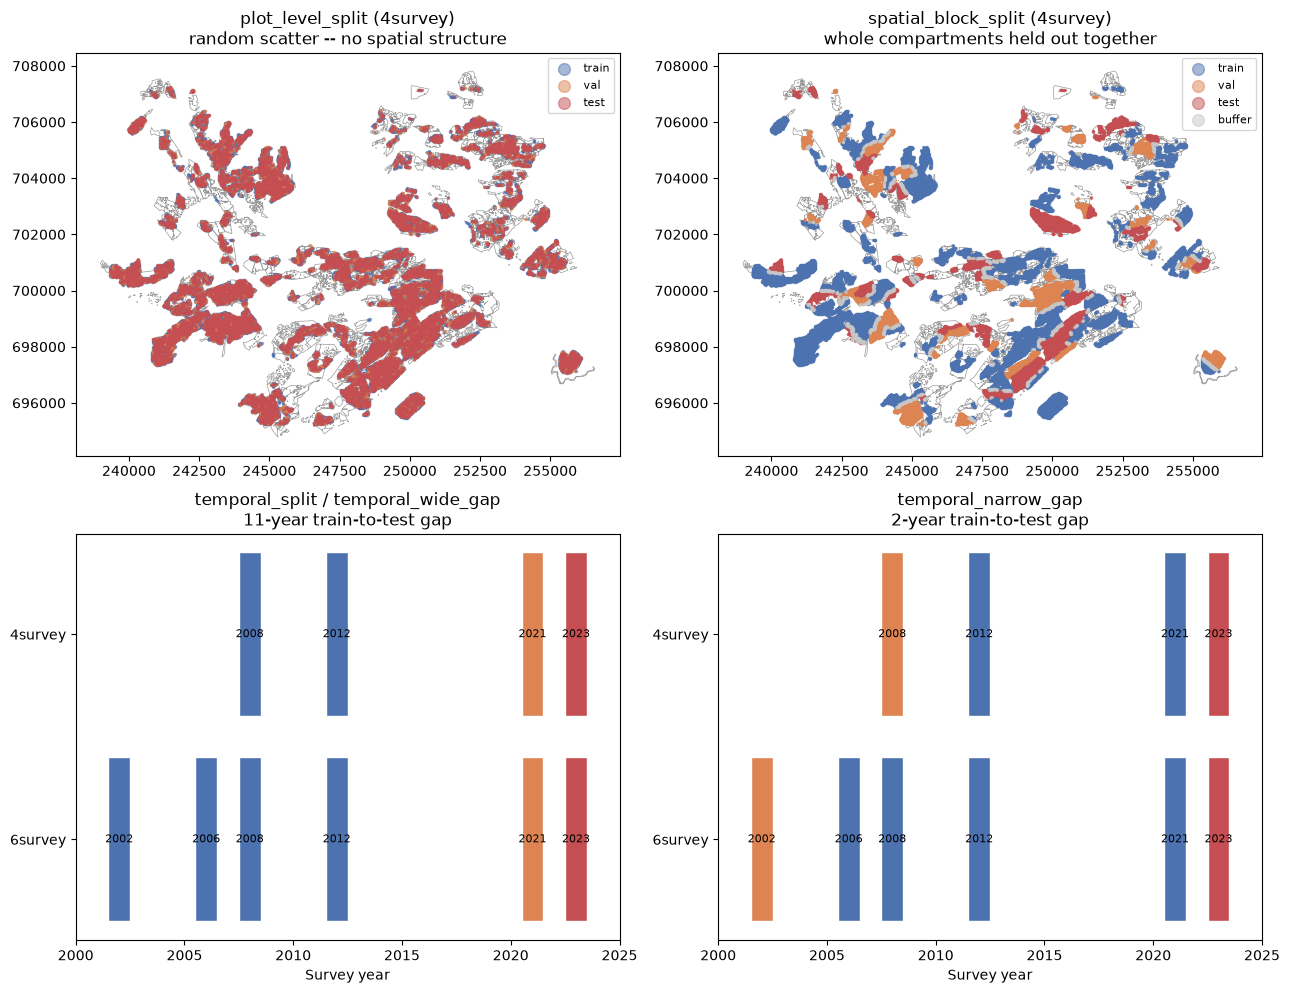

In [3]:
from models.common.geo import load_compartment_boundaries, load_plot_coordinates

SPLIT_COLORS = {"train": "#4c72b0", "val": "#dd8452", "test": "#c44e52", "buffer": "#c7c7c7", "unassigned": "#c7c7c7"}


def split_assignment_path(cohort, split_type):
    if split_type == "plot_level":
        return project_root / "outputs" / "splits" / cohort / "split_assignment.csv"
    return project_root / "outputs" / split_type / "splits" / cohort / "split_assignment.csv"


def load_split_assignment(cohort, split_type):
    return pd.read_csv(split_assignment_path(cohort, split_type))


compartment_boundaries = load_compartment_boundaries()


def draw_survey_outline(ax):
    used_cpmts = coordinates_df.loc[coordinates_df["identification"].isin(
        load_split_assignment("4survey", "spatial_block")["identification"]
    ), "cpmt"].unique()
    compartment_boundaries[compartment_boundaries["cpmt"].isin(used_cpmts)].plot(
        ax=ax, facecolor="none", edgecolor="#999999", linewidth=0.5, zorder=0
    )


def plot_year_timeline(ax, split_type, title):
    cohort_y_positions = {"4survey": 1, "6survey": 0}
    for cohort, y_pos in cohort_y_positions.items():
        year_to_split = (
            load_split_assignment(cohort, split_type)
            .drop_duplicates("LiDAR_year")[["LiDAR_year", "split"]]
            .sort_values("LiDAR_year")
        )
        for _, row in year_to_split.iterrows():
            ax.barh(y_pos, 1, left=row["LiDAR_year"] - 0.5, color=SPLIT_COLORS[row["split"]], edgecolor="white")
            ax.text(row["LiDAR_year"], y_pos, str(row["LiDAR_year"]), ha="center", va="center", fontsize=8)
    ax.set_yticks(list(cohort_y_positions.values()))
    ax.set_yticklabels(list(cohort_y_positions.keys()))
    ax.set_xlabel("Survey year")
    ax.set_title(title)
    ax.set_xlim(2000, 2025)


fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# Panel 1: plot_level_split -- individual plots shuffled randomly.
plot_level_map = coordinates_df.merge(
    load_split_assignment("4survey", "plot_level").drop_duplicates("identification")[["identification", "split"]],
    on="identification",
)
draw_survey_outline(axes[0, 0])
for split_name, colour in SPLIT_COLORS.items():
    subset = plot_level_map[plot_level_map["split"] == split_name]
    if len(subset) > 0:
        axes[0, 0].scatter(subset["x"], subset["y"], s=2, alpha=0.5, color=colour, label=split_name)
axes[0, 0].set_title("plot_level_split (4survey)\nrandom scatter -- no spatial structure")
axes[0, 0].legend(markerscale=6, fontsize=8)
axes[0, 0].set_aspect("equal")

# Panel 2: spatial_block_split -- whole compartments held out together.
spatial_map = coordinates_df.merge(
    load_split_assignment("4survey", "spatial_block").drop_duplicates("identification")[["identification", "split"]],
    on="identification",
)
draw_survey_outline(axes[0, 1])
for split_name, colour in SPLIT_COLORS.items():
    subset = spatial_map[spatial_map["split"] == split_name]
    if len(subset) > 0:
        axes[0, 1].scatter(subset["x"], subset["y"], s=2, alpha=0.5, color=colour, label=split_name)
axes[0, 1].set_title("spatial_block_split (4survey)\nwhole compartments held out together")
axes[0, 1].legend(markerscale=6, fontsize=8)
axes[0, 1].set_aspect("equal")

# Panels 3-4: the two temporal splits -- no spatial dimension, so a year timeline instead of a map.
plot_year_timeline(axes[1, 0], "temporal", "temporal_split / temporal_wide_gap\n11-year train-to-test gap")
plot_year_timeline(axes[1, 1], "temporal_narrow_gap", "temporal_narrow_gap\n2-year train-to-test gap")

plt.tight_layout()
plt.show()

**Tiny discussion of each**:

- **`plot_level_split`** — individual plots shuffled randomly into train/val/test. Easiest test: a
  held-out plot's nearest neighbour is usually a training plot metres away. **Use**:
  check / lower bound only — RF scored highly but didnt work for spatial block hence not a true test of learning spatially
- **`spatial_block_split`** — whole forestry compartments held out together, with a buffer. A test
  plot's nearest training neighbour can be kilometres away. **Use**: main test,
  — this is the split that actually asks "does the model generalise to unseen ground," matters once terrain/wind become inputs.
- **`temporal_split` (`temporal_wide_gap`)** — train on the earliest years, test 11 years later. (similar to Reuben)
  **Use**: as the harder, secondary question "does this generalise to the future" — deliberately
  the tougher gap, so a physics constraint has the best chance to show it's earning its keep. (but not quite what was found, dnn beat pinn in no env setting)
- **`temporal_narrow_gap`** — same idea, but 2-year gap. **Use**: check on
  the split above, not a replacement for it — it answers "is the wide-gap degradation really about
  *distance into the future*, or something else about these years" (real data confirms the
  gap length explains most of it, see Part 1's findings and `baseline_results.ipynb` section 6.4).

## Part 1 — What's been done so far (real data, from `outputs/`)

Four baselines (Chapman-Richards, average-by-age, linear regression, random forest) plus a DNN and
a physics-informed neural network (PINN), all predicting Sitka spruce top-height from age +
thinning history only (no terrain/wind yet). Shown here under `spatial_block_split` — whole
forestry compartments held out together, the dissertation's primary, hardest test.

In [4]:
summary_rows = []
for cohort in COHORTS:
    for label, run_name in MODEL_RUN_NAMES.items():
        m = load_metrics(run_name, cohort)
        summary_rows.append({"cohort": cohort, "model": label, "RMSE": m["rmse"], "R2": m["r2"], "MAE": m["mae"]})

summary_df = pd.DataFrame(summary_rows)
summary_df.style.format({"RMSE": "{:.3f}", "R2": "{:.3f}", "MAE": "{:.3f}"})

,cohort,model,RMSE,R2,MAE
0,4survey,chapman_richards,6.107,0.421,4.868
1,4survey,average_by_age,6.348,0.375,5.114
2,4survey,linear_baseline,5.817,0.475,4.612
3,4survey,rf_baseline,5.988,0.443,4.534
4,4survey,dnn_noenv,5.019,0.609,3.781
5,4survey,pinn_noenv (tuned),5.121,0.593,3.861
6,6survey,chapman_richards,3.967,0.697,2.859
7,6survey,average_by_age,3.892,0.708,2.686
8,6survey,linear_baseline,4.086,0.678,3.148
9,6survey,rf_baseline,4.604,0.592,3.267


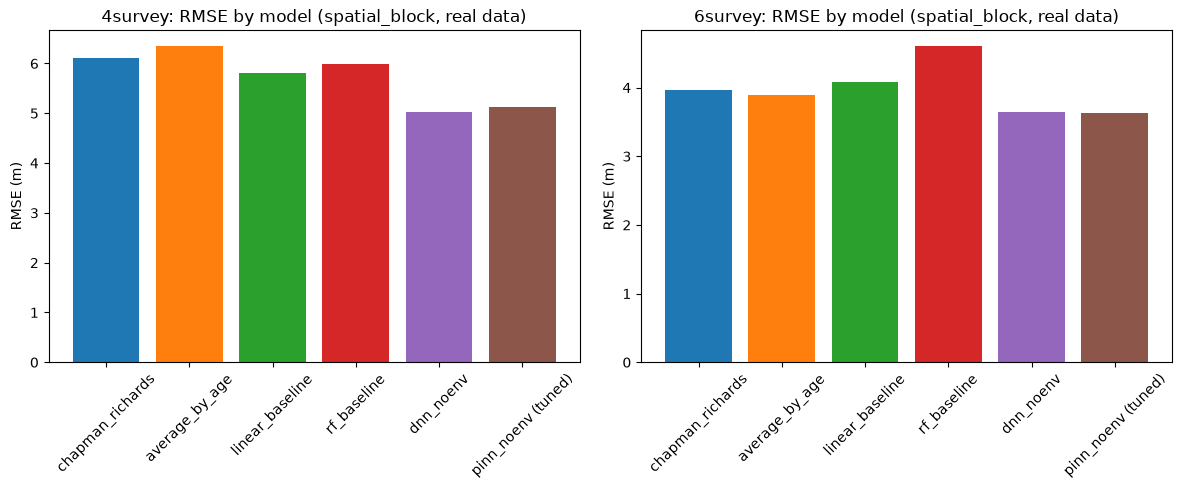

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, cohort in zip(axes, COHORTS):
    cohort_rows = summary_df[summary_df["cohort"] == cohort].set_index("model").loc[MODEL_RUN_NAMES.keys()]
    colors = [MODEL_COLORS[m] for m in cohort_rows.index]
    ax.bar(cohort_rows.index, cohort_rows["RMSE"], color=colors)
    ax.set_title(f"{cohort}: RMSE by model (spatial_block, real data)")
    ax.set_ylabel("RMSE (m)")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()
#lower is better. An RMSE of 0 indicates a perfect fit

**Real findings so far**:
- DNN and PINN both beat every baseline under `spatial_block` 
- DNN wins 4survey; DNN and PINN are tied on 6survey (confirmed via a
  multi-seed reseed check
- The physics constraint actively *hurts* accuracy at full strength — informative, not a failure:
  it shows Chapman-Richards' one-size-fits-all growth ceiling (`y_max`) fights real plot-to-plot
  variation. That variation is exactly what the next stage (terrain/wind) is meant to explain.

### The motivating evidence: every model struggles in the same two places

One point per test plot, coloured by mean prediction error (observed − predicted). Same colour
scale across panels. If different models struggled in different places, that would suggest
model-specific quirks. They don't — they struggle in the *same* places, which is the strongest
single piece of evidence that something location-specific (not currently in any model's inputs) is
driving real growth differences.

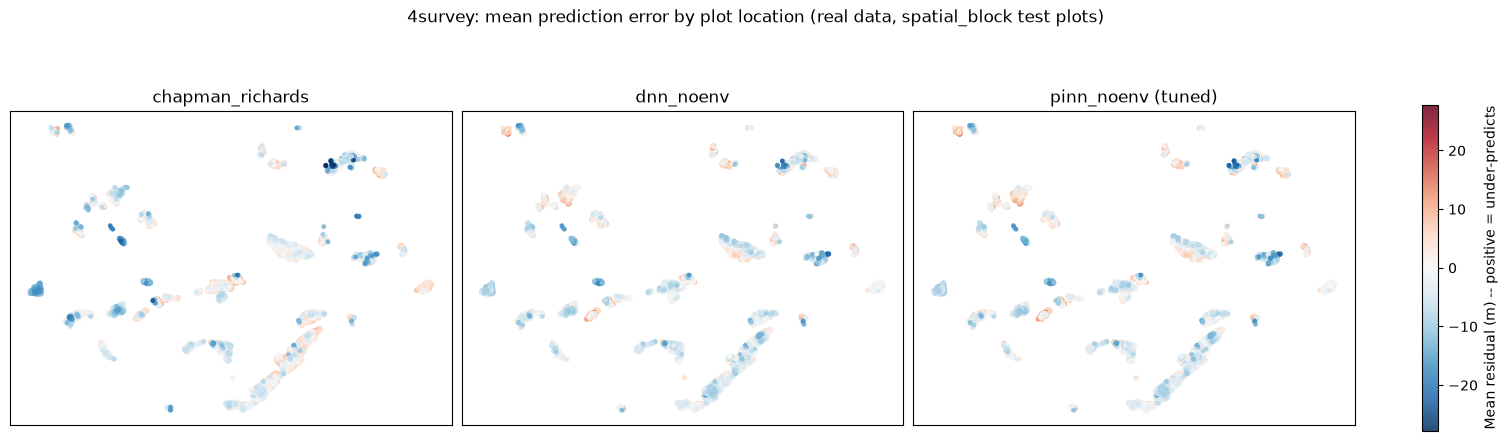

In [6]:
cohort = "4survey"  # one cohort is enough for a quick look

panel_labels = ["chapman_richards", "dnn_noenv", "pinn_noenv (tuned)"]
merged_by_model = {}
for label in panel_labels:
    predictions_df = load_predictions(MODEL_RUN_NAMES[label], cohort)
    test_only = predictions_df[predictions_df["split"] == "test"]
    mean_residual = test_only.groupby("identification")["residual"].mean().reset_index()
    merged_by_model[label] = coordinates_df.merge(mean_residual, on="identification")

max_abs_residual = max(m["residual"].abs().max() for m in merged_by_model.values())

fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)
fig.suptitle(f"{cohort}: mean prediction error by plot location (real data, spatial_block test plots)")
scatter = None
for ax, label in zip(axes, panel_labels):
    merged = merged_by_model[label]
    scatter = ax.scatter(merged["x"], merged["y"], c=merged["residual"], cmap="RdBu_r",
                          vmin=-max_abs_residual, vmax=max_abs_residual, s=6, alpha=0.85)
    ax.set_title(label)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])

fig.colorbar(scatter, ax=axes, shrink=0.7, label="Mean residual (m) -- positive = under-predicts")
plt.show()

## Part 2 — Where this is going next (MOCKUP — fabricated numbers, not real results)

Next stage: extract terrain (elevation, slope, wind exposure) per plot, then run XGBoost + SHAP on
the Chapman-Richards residuals to find out which environmental variables actually explain the
growth differences shown above — before building the full "Env-PINN" (a PINN whose growth ceiling
`y_max` becomes a function of terrain/wind, instead of one fixed number for the whole forest).

**Nothing below this point is measured. It's a mockup of the plots and reasoning the next stage
will actually produce**, built now so the *shape* of the argument is clear before the real data
exists.

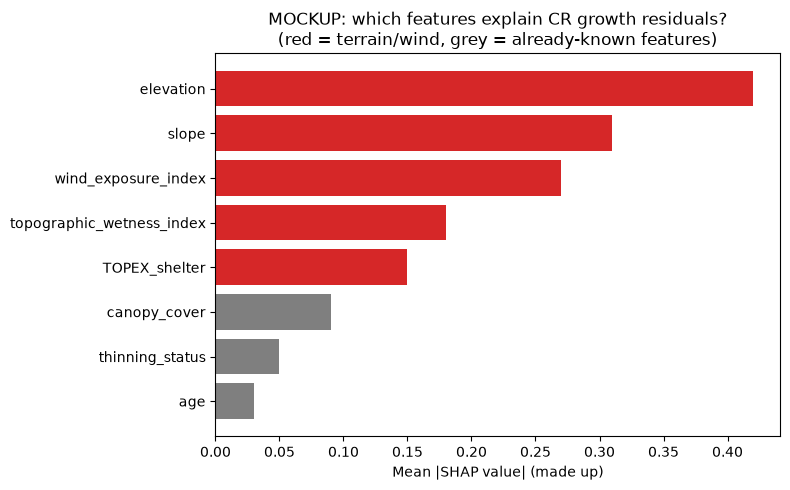

In [7]:
# MOCKUP DATA -- made up to illustrate what a SHAP feature-importance ranking might look like.
# Real version: run XGBoost on Chapman-Richards residuals with real terrain/wind features,
# then compute real SHAP values. Terrain ranked higher here is a HYPOTHESIS based on Worrell
# (1987)'s finding that Yield Class varies with terrain in Scottish uplands -- not a result.
rng = np.random.default_rng(42)

mockup_features = [
    "elevation", "slope", "wind_exposure_index", "topographic_wetness_index",
    "TOPEX_shelter", "canopy_cover", "thinning_status", "age",
]
mockup_shap_importance = [0.42, 0.31, 0.27, 0.18, 0.15, 0.09, 0.05, 0.03]  # made up, terrain/wind ranked highest

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#d62728" if f in ("elevation", "slope", "wind_exposure_index", "topographic_wetness_index", "TOPEX_shelter")
          else "#7f7f7f" for f in mockup_features]
ax.barh(mockup_features, mockup_shap_importance, color=colors)
ax.invert_yaxis()
ax.set_xlabel("Mean |SHAP value| (made up)")
ax.set_title("MOCKUP: which features explain CR growth residuals?\n(red = terrain/wind, grey = already-known features)")
plt.tight_layout()
plt.show()

**What this would show, if the real numbers come out like this**: terrain and wind features
explain more of the *residual* growth variation than the features already in the no-env models
(canopy cover, thinning, age). Important caveat that stays true even with real SHAP values: this
would show terrain/wind **correlate** with the growth differences the model can't currently
explain — it doesn't by itself prove terrain/wind *cause* those differences (e.g. better-drained,
more sheltered ground could also just happen to get planted with better stock, or be smaller/older
stands sampled differently). SHAP ranks association strength (not cause) so need to be careful with analysis and claims from it and be clear its a correlation

### A complementary local method: LIME

SHAP above answers "which features matter most, on average, across the whole forest." LIME
(Local Interpretable Model-agnostic Explanations) answers a different, complementary question:
"for *this one specific plot*, why did the model predict what it predicted?" It works by
perturbing a single prediction's inputs slightly and fitting a simple local model around just that
one point — useful for explaining an individual surprising prediction (e.g. one of the two hard
compartments from Part 1), not for a forest-wide ranking.

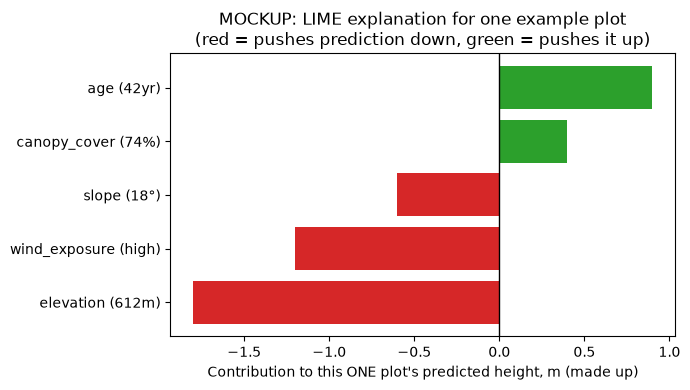

In [8]:
# MOCKUP DATA -- illustrates what a LIME explanation for ONE example plot's prediction might
# look like. Real version: run LIME on an actual trained Env-PINN prediction for one plot in a
# hard-to-predict compartment (see Part 1's shared error clusters), not a forest-wide average.
mockup_lime_features = ["elevation (612m)", "wind_exposure (high)", "slope (18\u00b0)", "canopy_cover (74%)", "age (42yr)"]
mockup_lime_contributions = [-1.8, -1.2, -0.6, 0.4, 0.9]  # made up -- metres pushed above/below the base prediction

fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#d62728" if v < 0 else "#2ca02c" for v in mockup_lime_contributions]
ax.barh(mockup_lime_features, mockup_lime_contributions, color=colors)
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Contribution to this ONE plot's predicted height, m (made up)")
ax.set_title("MOCKUP: LIME explanation for one example plot\n(red = pushes prediction down, green = pushes it up)")
plt.tight_layout()
plt.show()

**Why this would be useful, if built for real**: SHAP's forest-wide ranking (above) could show
`wind_exposure` matters on average without explaining why one *specific* plot in a hard cluster is
under-predicted. LIME could show, for that one plot, exactly which of its own conditions (unusually
high wind exposure, in this made-up example) the model is leaning on — a plot-level, not just
forest-level, diagnostic. Worth trying once real Env-PINN predictions exist for the two
under-predicted compartments identified in Part 1.

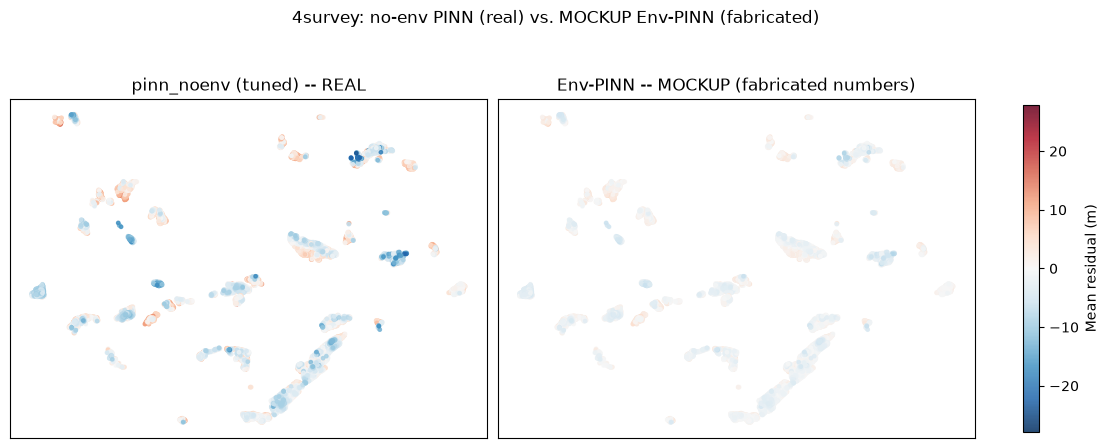

In [9]:
# MOCKUP DATA -- illustrates what an Env-PINN prediction map MIGHT look like if it successfully
# explains the error clusters shown in Part 1. Built by shrinking the REAL residuals from the
# no-env PINN by a made-up factor, not from an actual trained Env-PINN model.
real_pinn_residuals = merged_by_model["pinn_noenv (tuned)"].copy()

MOCKUP_IMPROVEMENT_FACTOR = 0.35  # made up -- "what if Env-PINN cut residual spread by 65%"
mockup_env_pinn = real_pinn_residuals.copy()
mockup_env_pinn["residual"] = real_pinn_residuals["residual"] * MOCKUP_IMPROVEMENT_FACTOR + rng.normal(
    0, 0.3, size=len(real_pinn_residuals)
)

fig, axes = plt.subplots(1, 2, figsize=(11, 5), constrained_layout=True)
fig.suptitle(f"{cohort}: no-env PINN (real) vs. MOCKUP Env-PINN (fabricated)")

scatter = axes[0].scatter(real_pinn_residuals["x"], real_pinn_residuals["y"], c=real_pinn_residuals["residual"],
                           cmap="RdBu_r", vmin=-max_abs_residual, vmax=max_abs_residual, s=6, alpha=0.85)
axes[0].set_title("pinn_noenv (tuned) -- REAL")
axes[1].scatter(mockup_env_pinn["x"], mockup_env_pinn["y"], c=mockup_env_pinn["residual"],
                 cmap="RdBu_r", vmin=-max_abs_residual, vmax=max_abs_residual, s=6, alpha=0.85)
axes[1].set_title("Env-PINN -- MOCKUP (fabricated numbers)")
for ax in axes:
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])

fig.colorbar(scatter, ax=axes, shrink=0.7, label="Mean residual (m)")
plt.show()

### Related approaches considered (not built, worth a paragraph)

My supervisor's actual suggestion was a **distributional model** — one where the parameters of a
local growth distribution are conditioned on terrain/exposure, rather than generalising the
Chapman-Richards functional form itself. Worth being explicit about this, because it's structurally
close to what Env-PINN already does: Env-PINN's whole design is "condition `y_max` on environment,"
just implemented as a neural sub-network mapping terrain/wind to `y_max`, rather than a statistical
distributional-regression framework like **GAMLSS** (Generalized Additive Models for Location,
Scale, and Shape — each parameter of an assumed distribution gets its own smooth-term regression on
covariates). Chose the PINN route over GAMLSS for three reasons: the physics constraint anchors
predictions to a known, biologically-meaningful curve shape that a purely statistical distributional
model doesn't provide by default; the PINN's trajectory-loss term is built specifically to exploit
the sparse, irregularly-spaced multi-survey structure this data actually has; and it follows the
same PINN-based precedent already established in the literature (Wesselkamp), keeping this
dissertation's methodology comparable to existing published work rather than introducing an
unrelated statistical framework partway through.

A few other related methods worth being aware of, not investigated yet:

- **GAMLSS** (as above) — models every parameter of an assumed distribution via smooth covariate
  terms; the direct statistical alternative to Env-PINN's neural conditioning.
- **Geographically Weighted Regression (GWR)** — fits a separate regression per location, weighted
  by proximity, so an environmental effect's *strength* can vary smoothly across the forest instead
  of being one fixed number everywhere — useful for showing *where* terrain matters most, not just
  that it matters on average.
- **Linear mixed-effects models with random compartment effects** — treats each forestry
  compartment as having its own random deviation from the population growth curve; a cheap way to
  quantify how much compartment-level variation exists before attributing any of it to a specific
  terrain/wind variable.
- **Gaussian Process regression / kriging** — models residuals as a smooth spatial random field with
  a fitted correlation length; a more formal way to quantify the same "shared error clusters"
  pattern already seen visually in Part 1, without assuming which terrain variable causes it.
- **Quantile regression forests** — estimate the whole conditional distribution of growth, not just
  the mean; relevant given the forester-confirmed finding that older stands show more variance, not
  just a different average (a heteroskedasticity question terrain might also help explain).

### How would we actually know Env-PINN is a *good* prediction — not just a lower RMSE?

A lower RMSE alone isn't enough to trust, for the same reason RF's `plot_level_split` numbers
weren't trustworthy earlier in this project (baseline_results.ipynb section 4) — a number can look
good for the wrong reason. Things worth checking, beyond the headline accuracy metric:

1. **Do the two specific hard compartments from Part 1 actually improve**, not just the average
   across the whole map? A model that gets better everywhere *except* the places terrain/wind was
   supposed to explain hasn't actually demonstrated the mechanism it claims to.
2. **Spatial autocorrelation of the *residuals*, not just their size** (Moran's I). If Env-PINN's
   leftover errors are still spatially clustered, that's a sign real environmental signal is still
   missing, even if the average error dropped.
3. **Convergent validity**: does Env-PINN's *learned* `y_max(terrain, wind)` rank features the same
   way the independent XGBoost + SHAP analysis does? Two independent methods agreeing is much
   stronger evidence than either one alone — this is explicitly one of the dissertation's planned
   contributions, not an afterthought.
4. **Multi-seed checked, this time from the start** — this project's own noise floor (measured
   2026-07-20) is roughly 0.1-1.5% RMSE. Any claimed improvement smaller than that needs seeds
   checked before it's reported as real, not after.
5. **Held out on `spatial_block_split` specifically** — the same discipline that revealed RF's
   fragility applies here too; an accuracy gain that only shows up on the easy split isn't the gain
   that matters.

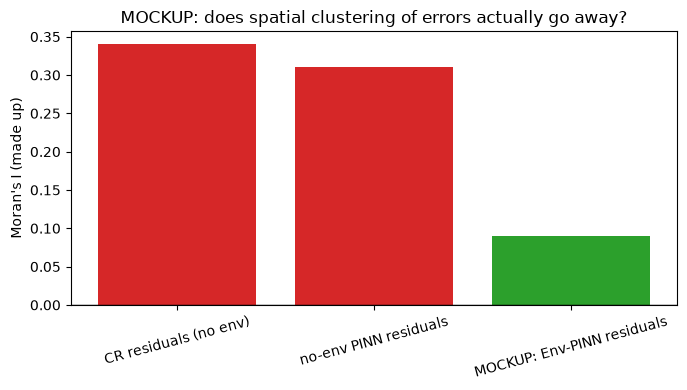

In [10]:
# MOCKUP DATA -- illustrates Moran's I before/after, made up. Real version: compute actual
# Moran's I on Chapman-Richards residuals now (cheap, no cluster needed -- see the plan's next
# step), then again on Env-PINN's residuals once it exists.
mockup_morans_i = pd.DataFrame({
    "stage": ["CR residuals (no env)", "no-env PINN residuals", "MOCKUP: Env-PINN residuals"],
    "morans_i": [0.34, 0.31, 0.09],  # made up -- illustrates "significant clustering" -> "much less"
})

fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#d62728", "#d62728", "#2ca02c"]
ax.bar(mockup_morans_i["stage"], mockup_morans_i["morans_i"], color=colors)
ax.axhline(0, color="black", linewidth=1)
ax.set_ylabel("Moran's I (made up)")
ax.set_title("MOCKUP: does spatial clustering of errors actually go away?")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

## Summary

**Real, done**: four baselines + DNN + PINN, tuned, reseed-checked for noise, compared honestly
(DNN wins/ties PINN on accuracy everywhere so far; PINN's real edge is training stability). The
spatial error maps are the strongest existing evidence that something real and location-specific
is missing from every current model.

**Proposed, not done**: terrain/wind feature extraction, XGBoost + SHAP on the residuals (mockup
above), then Env-PINN — validated not just by a lower RMSE but by whether it fixes the *specific*
hard compartments, reduces spatially-clustered error (not just average error), and agrees with the
independent SHAP ranking.